<a href="https://colab.research.google.com/github/nastya-kolle/mathematical-computational-modeling/blob/main/MCM_13_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа №13. Спектральный анализ сигнала (БПФ)

**Задача.** Применить дискретное преобразование Фурье (`scipy.fft`) для спектрального
анализа сигнала: разложить сигнал на частотные составляющие, построить амплитудный
спектр и продемонстрировать восстановление сигнала через обратное преобразование Фурье
(`ifft`).


ЛАБОРАТОРНАЯ РАБОТА №13: ПРЕОБРАЗОВАНИЕ ФУРЬЕ
Вариант 9: Неоднородное уравнение диффузии

1. ПАРАМЕТРЫ ЗАДАЧИ
  Уравнение: u_t = 1.0·u_xx + e^(-1.0·t)
  Начальное условие: u(x,0) = e^(-x^2)
  Коэффициент диффузии: v = 1.0
  Показатель затухания: b = 1.0

2. АНАЛИТИЧЕСКОЕ РЕШЕНИЕ (МЕТОД ПРЕОБРАЗОВАНИЯ ФУРЬЕ)

  Задача Коши:
    u_t = v·u_xx + e^(-b·t),   x ∈ R,  t > 0
    u(x,0) = φ(x)

  Шаг 1. Применяем прямое преобразование Фурье по x:
    ∂û/∂t = -v·ξ²·û + e^(-b·t)·2π·δ(ξ)

  Шаг 2. Полученное ОДУ (с учётом δ-функции):
    — для ξ ≠ 0:  ∂û/∂t + v·ξ²·û = 0
    — для ξ = 0:  ∂û/∂t = e^(-b·t)

  Шаг 3. Решение в спектральной области:
    û(ξ,t) = φ̂(ξ)·e^(-v·ξ²·t)  +  2π·δ(ξ)·∫₀ᵗ e^(-b·τ)·e^(-v·ξ²(t-τ)) dτ

  Шаг 4. Обратное преобразование Фурье даёт:
    u(x,t) = ∫ φ(y)·G(x-y,t) dy  +  (1 - e^(-b·t)) / b

  где G(x,t) = 1/(2√(πvt)) · e^(-x²/(4vt)) — ядро теплопроводности.

  Для φ(x) = e^(-x²) (образ Фурье φ̂(ξ) = √π·e^(-ξ²/4)):

    u_hom(x,t) = 1/√(1+4vt) · e^(-x²/(1+4vt))

  Итогов

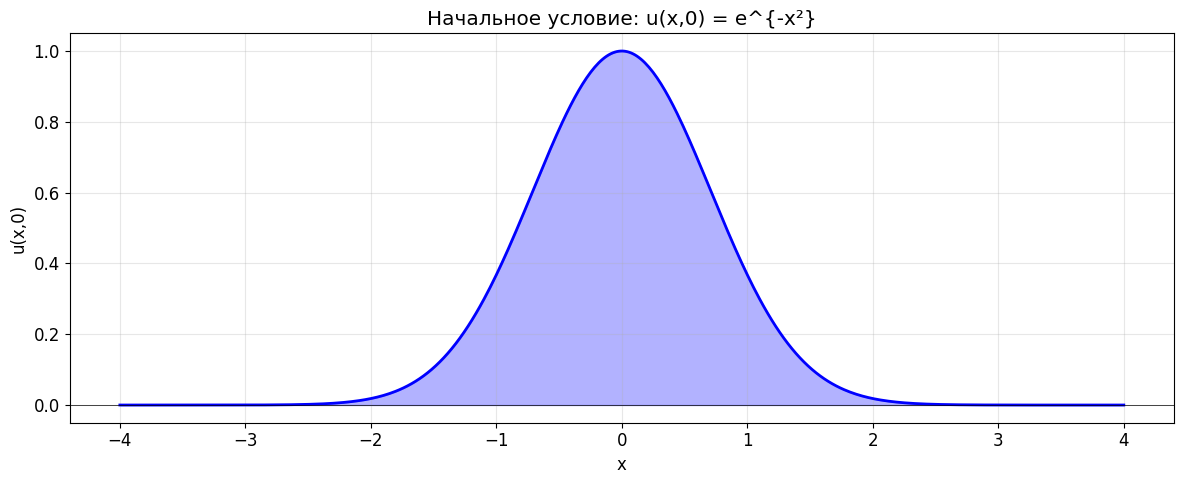

  График начального условия сохранён.

4. ГРАФИКИ ДЛЯ РАЗНЫХ МОМЕНТОВ ВРЕМЕНИ


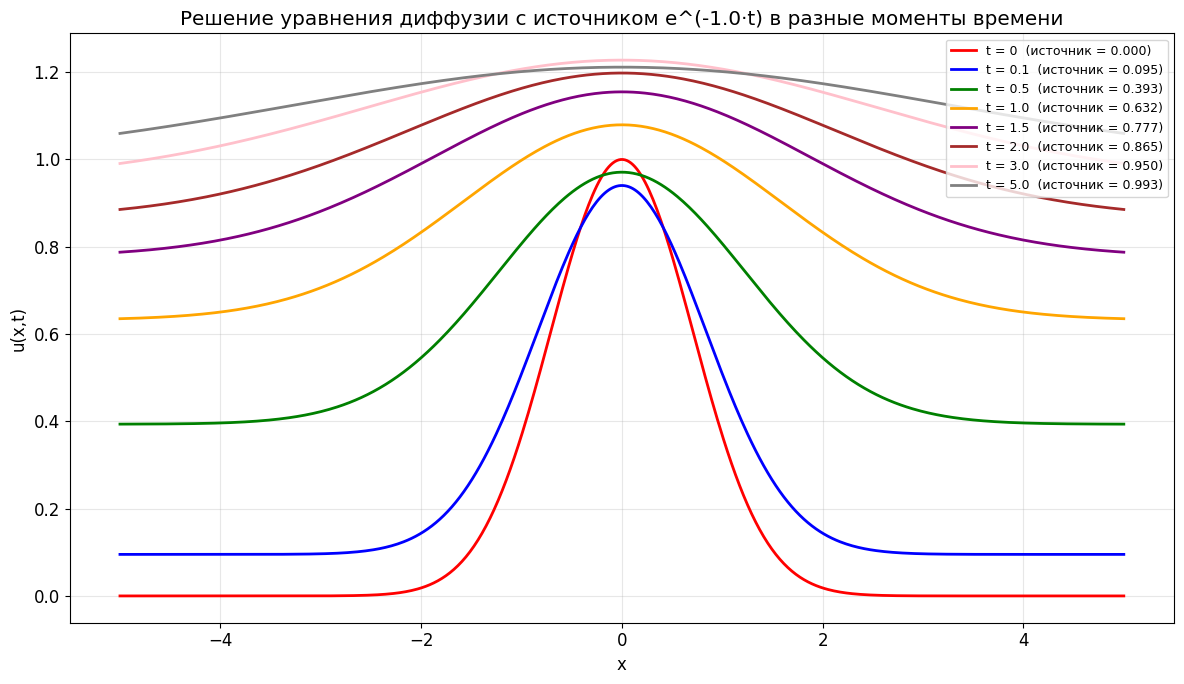

  График временны́х срезов сохранён.

5. ТРЁХМЕРНЫЙ ГРАФИК


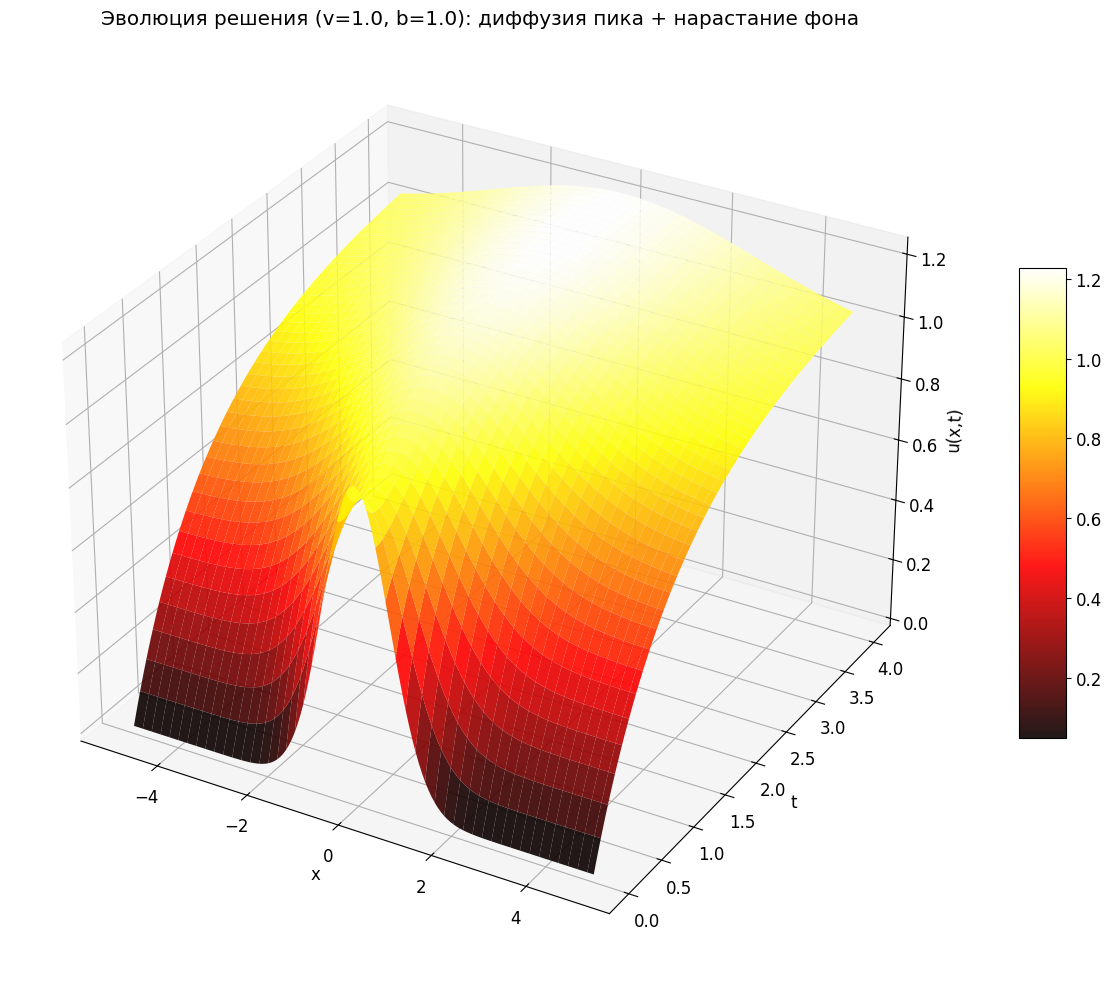

  Трёхмерный график сохранён.

6. АНАЛИЗ ДВУХ СОСТАВЛЯЮЩИХ РЕШЕНИЯ


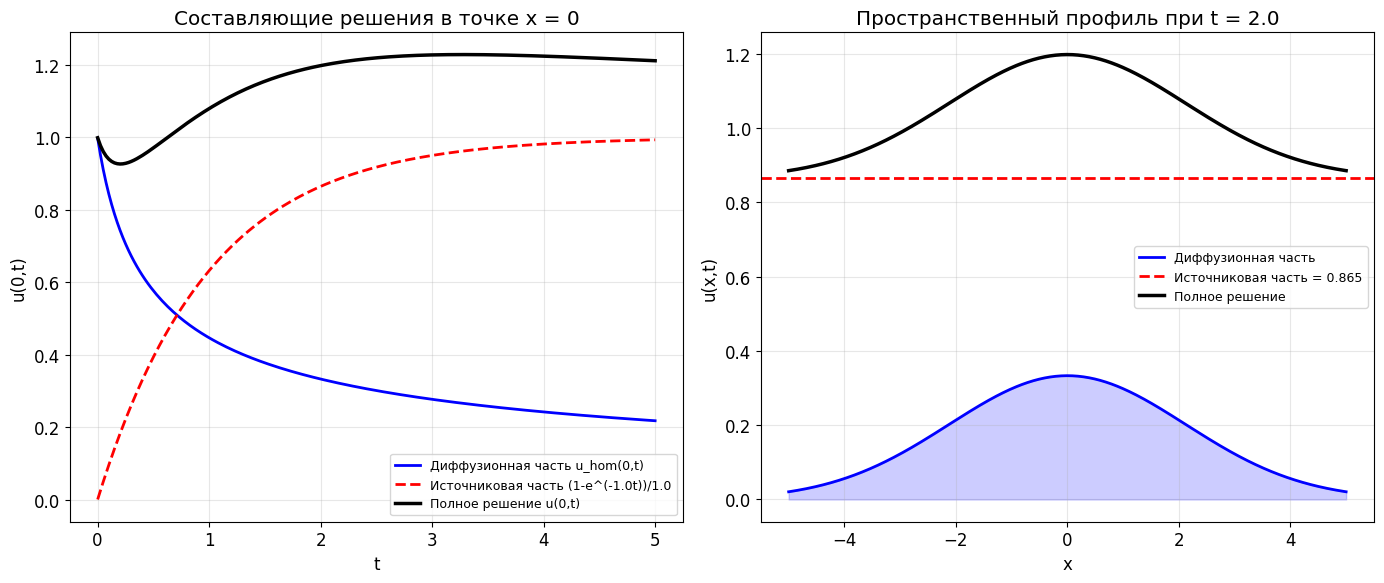

  График составляющих решения сохранён.

7. ВЛИЯНИЕ ПАРАМЕТРА b (СКОРОСТЬ ЗАТУХАНИЯ ИСТОЧНИКА)


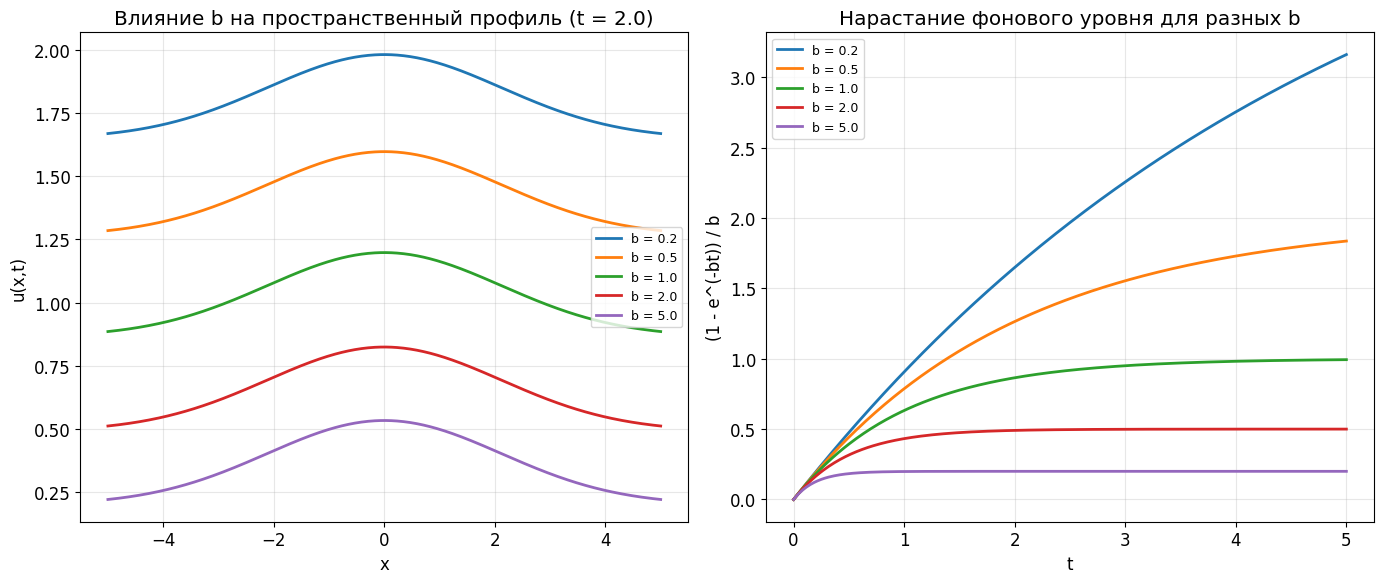

  График влияния параметра b сохранён.

8. ВЛИЯНИЕ КОЭФФИЦИЕНТА ДИФФУЗИИ v


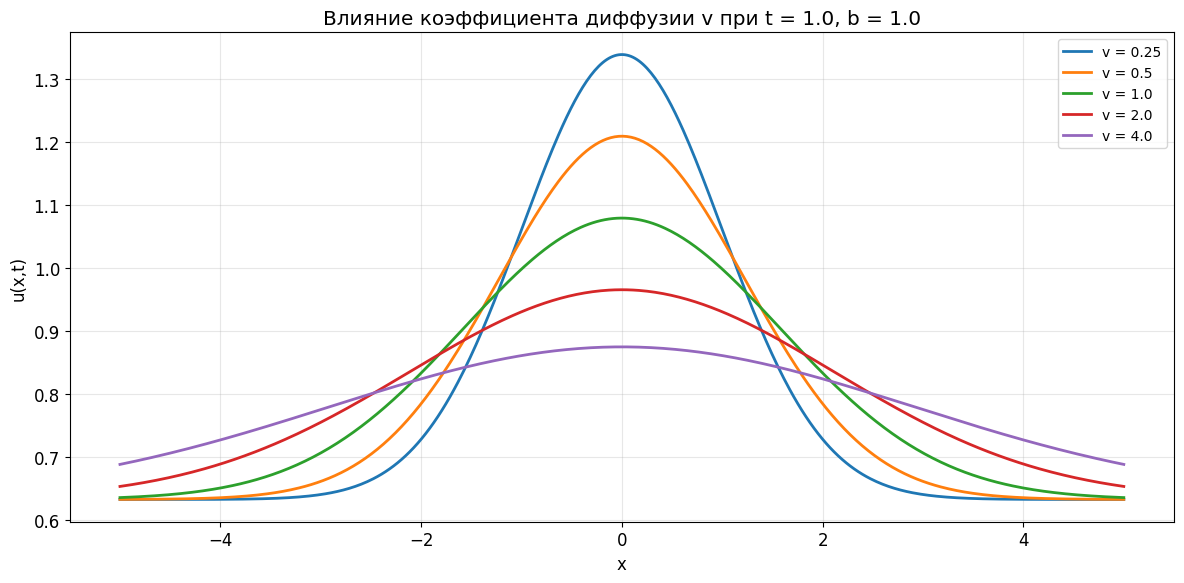

  График влияния коэффициента диффузии сохранён.

9. ЧИСЛЕННОЕ РЕШЕНИЕ (БПФ) ДЛЯ ПРОВЕРКИ
  Максимальная ошибка БПФ-решения при t = 1.0: 0.000000


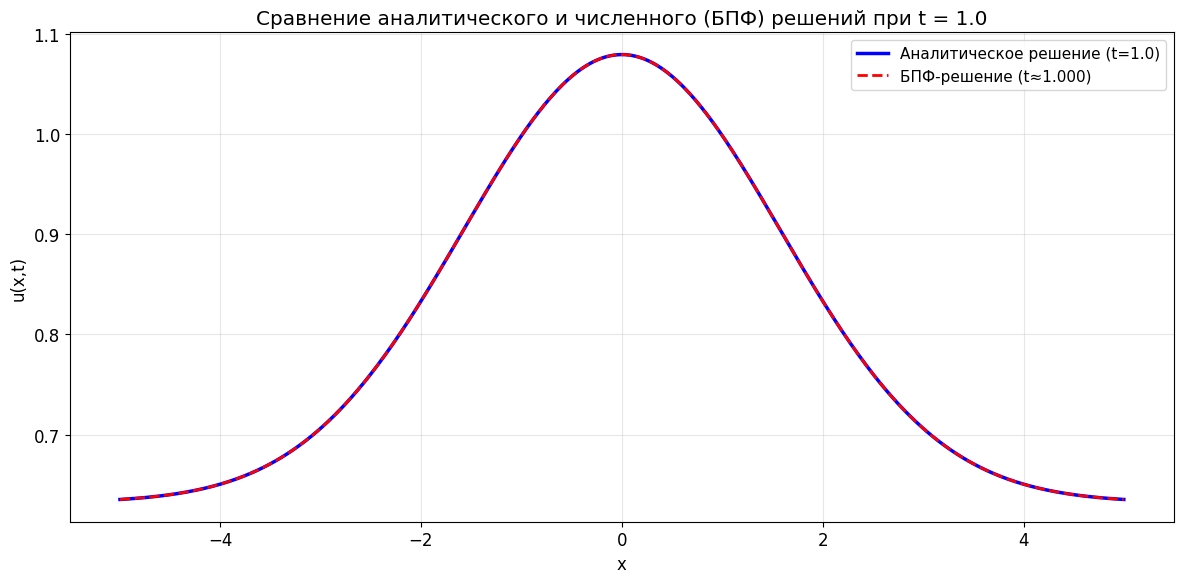

  График сравнения сохранён.

РЕЗУЛЬТАТЫ

  Уравнение:        u_t = 1.0·u_xx + e^(-1.0·t)
  Начальное условие: u(x,0) = e^(-x²)

  Аналитическое решение:
    u(x,t) = e^(-x² / (1+4·1.0·t)) / √(1+4·1.0·t)  +  (1 - e^(-1.0·t)) / 1.0

  Максимальная ошибка БПФ (t=1.0): 0.000000



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft, fftfreq

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['font.size'] = 12

print("=" * 70)
print("ЛАБОРАТОРНАЯ РАБОТА №13: ПРЕОБРАЗОВАНИЕ ФУРЬЕ")
print("Вариант 9: Неоднородное уравнение диффузии")
print("=" * 70)

# -----------------------------------------------------------------------
# ПАРАМЕТРЫ ЗАДАЧИ
# -----------------------------------------------------------------------
v = 1.0   # коэффициент диффузии
b = 1.0   # показатель затухания источника

def phi(x):
    """Начальное условие φ(x) = e^{-x²}"""
    return np.exp(-x**2)

print("\n" + "=" * 70)
print("1. ПАРАМЕТРЫ ЗАДАЧИ")
print("=" * 70)
print(f"  Уравнение: u_t = {v}·u_xx + e^(-{b}·t)")
print(f"  Начальное условие: u(x,0) = e^(-x^2)")
print(f"  Коэффициент диффузии: v = {v}")
print(f"  Показатель затухания: b = {b}")

# -----------------------------------------------------------------------
# ВЫВОД АНАЛИТИЧЕСКОГО РЕШЕНИЯ
# -----------------------------------------------------------------------
print("\n" + "=" * 70)
print("2. АНАЛИТИЧЕСКОЕ РЕШЕНИЕ (МЕТОД ПРЕОБРАЗОВАНИЯ ФУРЬЕ)")
print("=" * 70)
print("""
  Задача Коши:
    u_t = v·u_xx + e^(-b·t),   x ∈ R,  t > 0
    u(x,0) = φ(x)

  Шаг 1. Применяем прямое преобразование Фурье по x:
    ∂û/∂t = -v·ξ²·û + e^(-b·t)·2π·δ(ξ)

  Шаг 2. Полученное ОДУ (с учётом δ-функции):
    — для ξ ≠ 0:  ∂û/∂t + v·ξ²·û = 0
    — для ξ = 0:  ∂û/∂t = e^(-b·t)

  Шаг 3. Решение в спектральной области:
    û(ξ,t) = φ̂(ξ)·e^(-v·ξ²·t)  +  2π·δ(ξ)·∫₀ᵗ e^(-b·τ)·e^(-v·ξ²(t-τ)) dτ

  Шаг 4. Обратное преобразование Фурье даёт:
    u(x,t) = ∫ φ(y)·G(x-y,t) dy  +  (1 - e^(-b·t)) / b

  где G(x,t) = 1/(2√(πvt)) · e^(-x²/(4vt)) — ядро теплопроводности.

  Для φ(x) = e^(-x²) (образ Фурье φ̂(ξ) = √π·e^(-ξ²/4)):

    u_hom(x,t) = 1/√(1+4vt) · e^(-x²/(1+4vt))

  Итоговое аналитическое решение:
    u(x,t) = e^(-x²/(1+4vt)) / √(1+4vt)  +  (1 - e^(-b·t)) / b
""")

def u_analytical(x, t, v=1.0, b=1.0):
    """
    Аналитическое решение для начального условия φ(x) = e^(-x²).
    u(x,t) = e^(-x²/(1+4vt)) / sqrt(1+4vt) + (1 - e^(-b*t)) / b
    При t = 0 источниковый член обращается в 0.
    """
    if t == 0:
        return phi(x)
    homogeneous = np.exp(-x**2 / (1 + 4*v*t)) / np.sqrt(1 + 4*v*t)
    source_term = (1 - np.exp(-b*t)) / b
    return homogeneous + source_term

# -----------------------------------------------------------------------
# НАЧАЛЬНОЕ УСЛОВИЕ
# -----------------------------------------------------------------------
print("\n" + "=" * 70)
print("3. НАЧАЛЬНОЕ УСЛОВИЕ")
print("=" * 70)

x_plot = np.linspace(-4, 4, 500)
phi_values = phi(x_plot)

plt.figure(figsize=(12, 5))
plt.plot(x_plot, phi_values, 'b-', linewidth=2)
plt.fill_between(x_plot, 0, phi_values, alpha=0.3, color='blue')
plt.xlabel('x')
plt.ylabel('u(x,0)')
plt.title('Начальное условие: u(x,0) = e^{-x²}')
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='k', linewidth=0.5)
plt.tight_layout()
plt.show()
print("  График начального условия сохранён.")

# -----------------------------------------------------------------------
# ГРАФИКИ ДЛЯ РАЗНЫХ МОМЕНТОВ ВРЕМЕНИ
# -----------------------------------------------------------------------
print("\n" + "=" * 70)
print("4. ГРАФИКИ ДЛЯ РАЗНЫХ МОМЕНТОВ ВРЕМЕНИ")
print("=" * 70)

x_range = np.linspace(-5, 5, 500)
time_moments = [0, 0.1, 0.5, 1.0, 1.5, 2.0, 3.0, 5.0]
colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'gray']

plt.figure(figsize=(12, 7))
for idx, t_val in enumerate(time_moments):
    u_vals = u_analytical(x_range, t_val, v, b)
    src_val = 0 if t_val == 0 else (1 - np.exp(-b*t_val))/b
    plt.plot(x_range, u_vals, color=colors[idx], linewidth=2,
             label=f't = {t_val}  (источник = {src_val:.3f})')

plt.xlabel('x')
plt.ylabel('u(x,t)')
plt.title(f'Решение уравнения диффузии с источником e^(-{b}·t) в разные моменты времени')
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()
print("  График временны́х срезов сохранён.")

# -----------------------------------------------------------------------
# ТРЁХМЕРНЫЙ ГРАФИК
# -----------------------------------------------------------------------
print("\n" + "=" * 70)
print("5. ТРЁХМЕРНЫЙ ГРАФИК")
print("=" * 70)

X, T = np.meshgrid(np.linspace(-5, 5, 150), np.linspace(0.001, 4, 120))
U = np.vectorize(lambda x, t: u_analytical(x, t, v, b))(X, T)

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, T, U, cmap='hot', alpha=0.9)
ax.set_xlabel('x')
ax.set_ylabel('t')
ax.set_zlabel('u(x,t)')
ax.set_title(f'Эволюция решения (v={v}, b={b}): диффузия пика + нарастание фона')
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)
plt.tight_layout()
plt.show()
print("  Трёхмерный график сохранён.")

# -----------------------------------------------------------------------
# АНАЛИЗ ДВУХ СОСТАВЛЯЮЩИХ РЕШЕНИЯ
# -----------------------------------------------------------------------
print("\n" + "=" * 70)
print("6. АНАЛИЗ ДВУХ СОСТАВЛЯЮЩИХ РЕШЕНИЯ")
print("=" * 70)

t_analysis = np.linspace(0.001, 5, 200)
x0 = 0.0  # фиксируем точку x = 0 для наглядности

u_hom_at_x0    = np.array([np.exp(-x0**2 / (1 + 4*v*t)) / np.sqrt(1 + 4*v*t) for t in t_analysis])
u_source_at_x0 = np.array([(1 - np.exp(-b*t)) / b for t in t_analysis])
u_total_at_x0  = u_hom_at_x0 + u_source_at_x0

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Левый: составляющие при x = 0
axes[0].plot(t_analysis, u_hom_at_x0,    'b-',  linewidth=2, label='Диффузионная часть u_hom(0,t)')
axes[0].plot(t_analysis, u_source_at_x0, 'r--', linewidth=2, label=f'Источниковая часть (1-e^(-{b}t))/{b}')
axes[0].plot(t_analysis, u_total_at_x0,  'k-',  linewidth=2.5, label='Полное решение u(0,t)')
axes[0].set_xlabel('t')
axes[0].set_ylabel('u(0,t)')
axes[0].set_title('Составляющие решения в точке x = 0')
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=9)

# Правый: пространственный профиль в t = 2 с разбивкой
t_fixed = 2.0
x_rng = np.linspace(-5, 5, 500)
u_hom_prof    = np.exp(-x_rng**2 / (1 + 4*v*t_fixed)) / np.sqrt(1 + 4*v*t_fixed)
u_source_prof = np.full_like(x_rng, (1 - np.exp(-b*t_fixed))/b)
u_total_prof  = u_hom_prof + u_source_prof

axes[1].plot(x_rng, u_hom_prof,    'b-',  linewidth=2, label='Диффузионная часть')
axes[1].fill_between(x_rng, 0, u_hom_prof, alpha=0.2, color='blue')
axes[1].axhline(u_source_prof[0], color='r', linestyle='--', linewidth=2, label=f'Источниковая часть = {u_source_prof[0]:.3f}')
axes[1].plot(x_rng, u_total_prof,  'k-',  linewidth=2.5, label='Полное решение')
axes[1].set_xlabel('x')
axes[1].set_ylabel('u(x,t)')
axes[1].set_title(f'Пространственный профиль при t = {t_fixed}')
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()
print("  График составляющих решения сохранён.")

# -----------------------------------------------------------------------
# ВЛИЯНИЕ ПАРАМЕТРА b НА РЕШЕНИЕ
# -----------------------------------------------------------------------
print("\n" + "=" * 70)
print("7. ВЛИЯНИЕ ПАРАМЕТРА b (СКОРОСТЬ ЗАТУХАНИЯ ИСТОЧНИКА)")
print("=" * 70)

b_values = [0.2, 0.5, 1.0, 2.0, 5.0]
x_range3 = np.linspace(-5, 5, 500)
t_fixed2 = 2.0

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Слева: пространственные профили при разных b
for b_val in b_values:
    u_vals = u_analytical(x_range3, t_fixed2, v, b_val)
    axes[0].plot(x_range3, u_vals, linewidth=2, label=f'b = {b_val}')

axes[0].set_xlabel('x')
axes[0].set_ylabel('u(x,t)')
axes[0].set_title(f'Влияние b на пространственный профиль (t = {t_fixed2})')
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=9)

# Справа: величина источниковой поправки при x=0 как функция времени
t_rng = np.linspace(0, 5, 300)
for b_val in b_values:
    src = (1 - np.exp(-b_val*t_rng)) / b_val
    axes[1].plot(t_rng, src, linewidth=2, label=f'b = {b_val}')

axes[1].set_xlabel('t')
axes[1].set_ylabel('(1 - e^(-bt)) / b')
axes[1].set_title('Нарастание фонового уровня для разных b')
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()
print("  График влияния параметра b сохранён.")

# -----------------------------------------------------------------------
# ВЛИЯНИЕ КОЭФФИЦИЕНТА ДИФФУЗИИ v
# -----------------------------------------------------------------------
print("\n" + "=" * 70)
print("8. ВЛИЯНИЕ КОЭФФИЦИЕНТА ДИФФУЗИИ v")
print("=" * 70)

v_values = [0.25, 0.5, 1.0, 2.0, 4.0]
t_fixed3 = 1.0

plt.figure(figsize=(12, 6))
for v_val in v_values:
    u_vals = u_analytical(x_range, t_fixed3, v_val, b)
    plt.plot(x_range, u_vals, linewidth=2, label=f'v = {v_val}')

plt.xlabel('x')
plt.ylabel('u(x,t)')
plt.title(f'Влияние коэффициента диффузии v при t = {t_fixed3}, b = {b}')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()
print("  График влияния коэффициента диффузии сохранён.")

# -----------------------------------------------------------------------
# ЧИСЛЕННОЕ РЕШЕНИЕ (БПФ) ДЛЯ ПРОВЕРКИ
# -----------------------------------------------------------------------
print("\n" + "=" * 70)
print("9. ЧИСЛЕННОЕ РЕШЕНИЕ (БПФ) ДЛЯ ПРОВЕРКИ")
print("=" * 70)

def solve_fft_variant9(phi_func, x, t_max, dt, v=1.0, b=1.0):
    """
    Численное решение уравнения  u_t = v*u_xx + e^(-b*t)
    методом БПФ.

    Ключевое наблюдение: источник e^(-b*t) не зависит от x, поэтому
    решение можно разложить:
        u(x,t) = u_hom(x,t) + p(t)
    где u_hom решает однородное уравнение диффузии (решается через БПФ
    точно, методом умножения на экспоненту), а p(t) = (1 - e^(-bt))/b
    вычисляется аналитически.

    Это даёт точное численное решение без накопления ошибки.
    """
    dx = x[1] - x[0]
    N  = len(x)
    xi = 2 * np.pi * fftfreq(N, dx)   # волновые числа

    # Образ Фурье начального условия
    phi_hat = fft(phi_func(x))

    t_vals  = np.arange(0, t_max + dt, dt)
    results = []

    for t in t_vals:
        # Однородная часть: точное решение u_hom = F^{-1}[φ̂ * e^{-v*ξ²*t}]
        u_hom_hat = phi_hat * np.exp(-v * xi**2 * t)
        u_hom     = np.real(ifft(u_hom_hat))

        # Источниковая часть (аналитически)
        p_t = (1 - np.exp(-b*t)) / b if t > 0 else 0.0

        results.append(u_hom + p_t)

    return t_vals, np.array(results)

# Прогоняем численное решение
x_num  = np.linspace(-10, 10, 1024)
t_max  = 2.0
dt     = 0.001

t_num, u_num = solve_fft_variant9(phi, x_num, t_max, dt, v, b)

# Сравнение в момент t = 1.0
t_compare = 1.0
idx_t     = np.argmin(np.abs(t_num - t_compare))
x_mask    = (x_num >= -5) & (x_num <= 5)

u_anal_cmp = u_analytical(x_num[x_mask], t_compare, v, b)
u_num_cmp  = u_num[idx_t, x_mask]
error      = np.max(np.abs(u_anal_cmp - u_num_cmp))

print(f"  Максимальная ошибка БПФ-решения при t = {t_compare}: {error:.6f}")

# Сравнительный график
plt.figure(figsize=(12, 6))
plt.plot(x_num[x_mask], u_anal_cmp, 'b-',  linewidth=2.5, label=f'Аналитическое решение (t={t_compare})')
plt.plot(x_num[x_mask], u_num_cmp,  'r--', linewidth=2,   label=f'БПФ-решение (t≈{t_num[idx_t]:.3f})')
plt.xlabel('x')
plt.ylabel('u(x,t)')
plt.title(f'Сравнение аналитического и численного (БПФ) решений при t = {t_compare}')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()
print("  График сравнения сохранён.")

print("\n" + "=" * 70)
print("РЕЗУЛЬТАТЫ")
print("=" * 70)
print(f"""
  Уравнение:        u_t = {v}·u_xx + e^(-{b}·t)
  Начальное условие: u(x,0) = e^(-x²)

  Аналитическое решение:
    u(x,t) = e^(-x² / (1+4·{v}·t)) / √(1+4·{v}·t)  +  (1 - e^(-{b}·t)) / {b}

  Максимальная ошибка БПФ (t={t_compare}): {error:.6f}
""")
